# SVM con kernels en Moons

Este notebook ejemplifica la diferencia entre SVM lineal y con kernels usando el dataset sintético Moons. También compara la diferencia entre usar kernels universales o no en el mismo dataset.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

## 1. Generación de las lunas

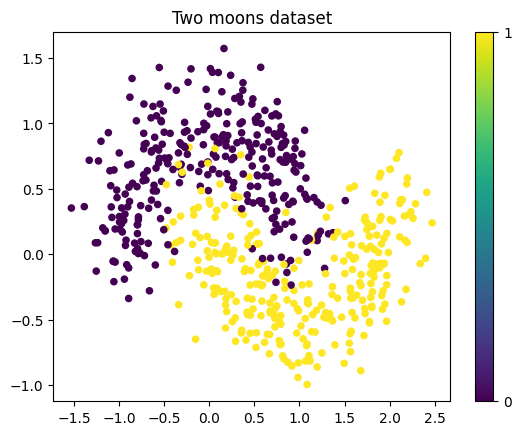

In [26]:
X, y = make_moons(n_samples=600, noise=0.25, random_state=0)
sc = plt.scatter(X[:,0], X[:,1], c=y, s=20)
plt.colorbar(sc, ticks=[0,1])
plt.title("Two moons dataset")
plt.show()

In [27]:
# Dividimos el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

In [28]:
# Función para dibujar la frontera de decisión
def plot_decision_boundary(model, X, y, title=""):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    plt.title(title)
    plt.show()

## 2. Modelo lineal

In [29]:
# Modelo lineal
svm_linear = make_pipeline( 
    StandardScaler(), 
    SVC(kernel="linear", C=1.0)
)
svm_linear.fit(X_train, y_train)
print("Accuracy train:", svm_linear.score(X_train, y_train))
print("Accuracy test :", svm_linear.score(X_test, y_test))

Accuracy train: 0.8866666666666667
Accuracy test : 0.8533333333333334


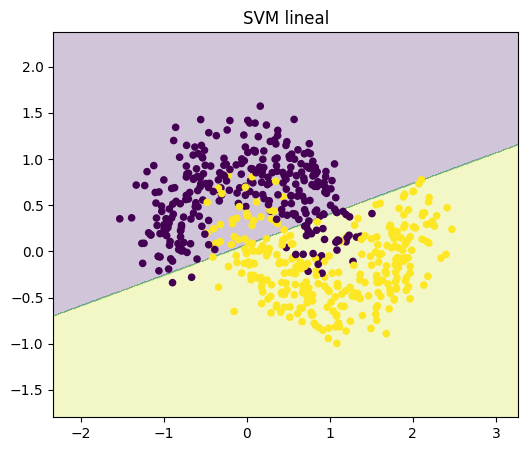

In [30]:
plot_decision_boundary(svm_linear, X, y, "SVM lineal")

## 3. Modelo RBF

In [ ]:
# Modelo con kernel
svm_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma=1.0)
)

svm_rbf.fit(X_train, y_train)
print("Accuracy train:", svm_rbf.score(X_train, y_train))
print("Accuracy test :", svm_rbf.score(X_test, y_test))

Accuracy train: 0.98
Accuracy test : 0.8466666666666667


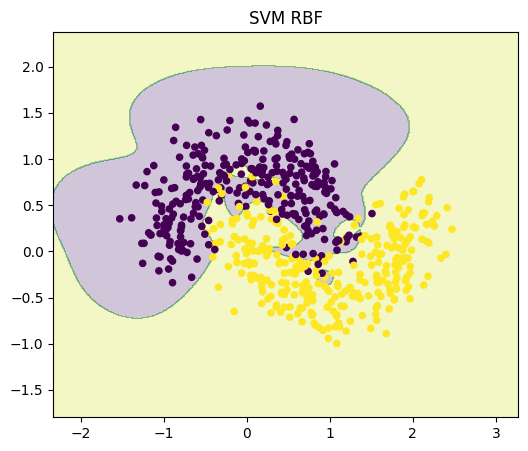

In [33]:
plot_decision_boundary(svm_rbf, X, y, "SVM RBF")

## 3. Otros Kernels

Poly grado 2 | train acc = 0.884 | test acc = 0.827


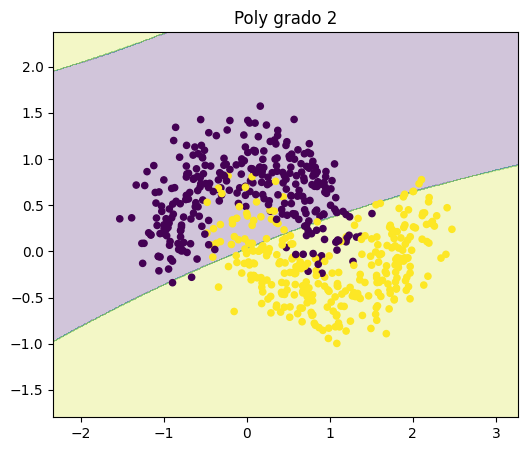

Poly grado 3 | train acc = 0.940 | test acc = 0.913


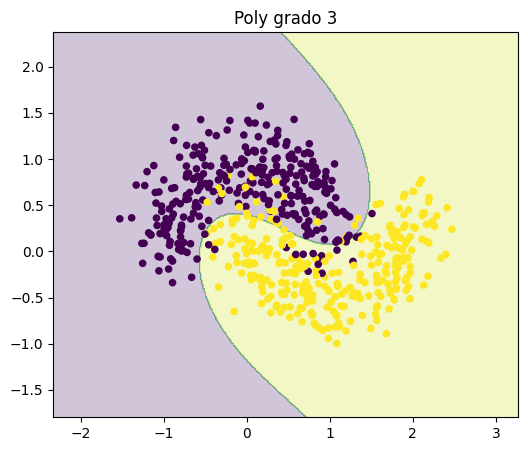

Poly grado 5 | train acc = 0.956 | test acc = 0.927


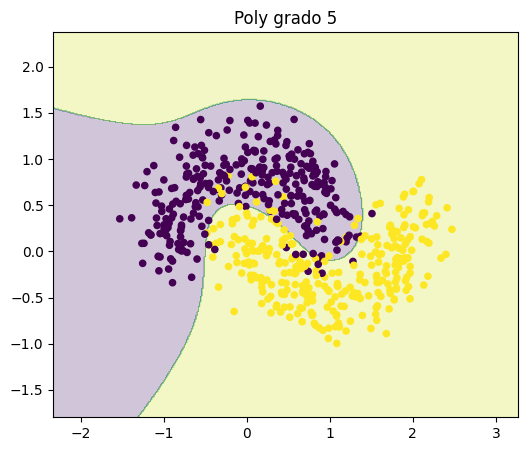

Sigmoid      | train acc = 0.733 | test acc = 0.700


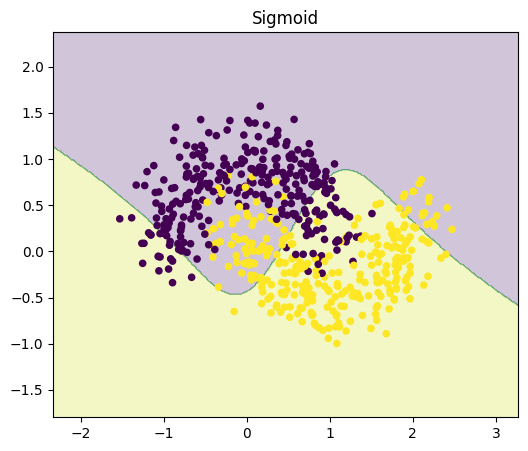

In [ ]:
# Otros kernels
models = {
    "Poly grado 2": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", degree=2, C=1.0, gamma="scale", coef0=1.0)
    ),
    "Poly grado 3": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0)
    ),
    "Poly grado 5": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", degree=5, C=1.0, gamma="scale", coef0=1.0)
    ),
    "Sigmoid": make_pipeline(
        StandardScaler(),
        SVC(kernel="sigmoid", C=1.0, gamma="scale", coef0=0.0)
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:12s} | train acc = {model.score(X_train, y_train):.3f} | test acc = {model.score(X_test, y_test):.3f}")
    plot_decision_boundary(model, X, y, title=name)